<h2 align="center">Logistic Regression(Multiclass Classification)</h2>

Problem Statement: Classify an IRIS flower into one of the three categories ['setosa', 'versicolor', 'virginica'] based on their petal and sepal width and height. We will use logistic regression for this classification problem

<img width=300 height=300 src="iris.png" />

In [55]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

### Load Data

In [58]:
from sklearn.datasets import load_iris

iris  = load_iris(as_frame=True)
iris
df = iris.frame ##print iris to see all the data, frame part in load_iris has all these data

In [60]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [62]:
df.target.unique()

array([0, 1, 2])

In [83]:
iris.target_names  ## built in-> not actually in the df

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [85]:
df.shape ## 50 rows per class

(150, 5)

In [87]:
df['target names'] = df['target'].map({0:"setosa", 1:"versicolor", 2: "virginica"})
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [69]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [71]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

### Data visualization and exploration

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

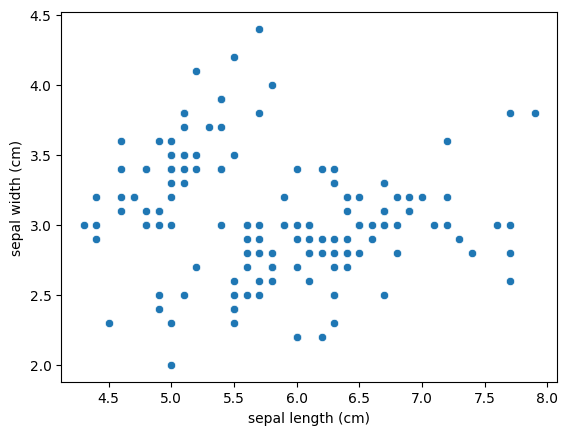

In [79]:
sns.scatterplot(df, x = "sepal length (cm)", y = "sepal width (cm)") ## all 3 types included

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

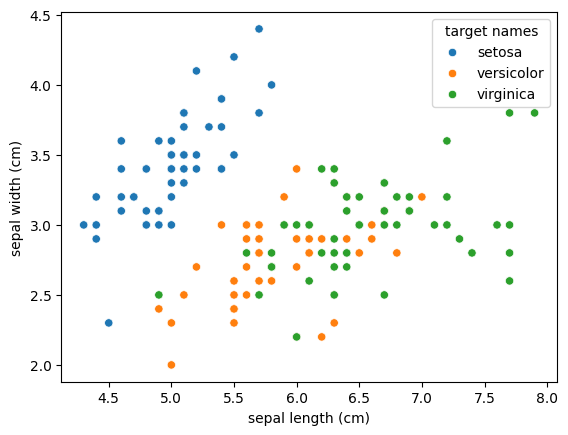

In [93]:
## differentiating with color

sns.scatterplot(df, x = "sepal length (cm)", y = "sepal width (cm)", hue = 'target names') 

In [94]:
##setosa -> sepal width high, sepal length small, viriginca -> sepal length high

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

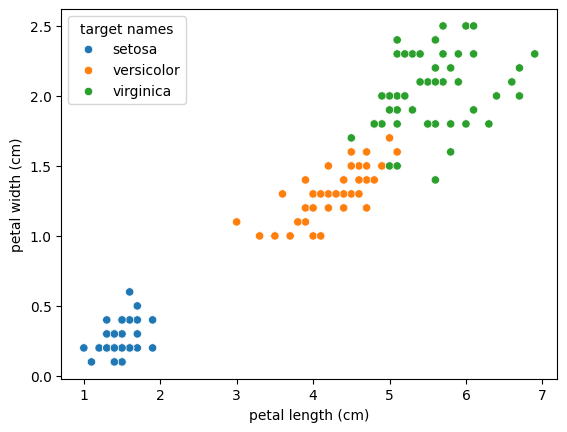

In [97]:
sns.scatterplot(df, x = "petal length (cm)", y = "petal width (cm)", hue = 'target names') 

In [99]:
## virginica>versicolor>sentosa -> based on petal length and petal width

In [102]:
X = df[['sepal length (cm)', 'sepal width (cm)'	,'petal length (cm)', 'petal width (cm)']]
y = df['target']

In [108]:
X.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
38,4.4,3.0,1.3,0.2
140,6.7,3.1,5.6,2.4
126,6.2,2.8,4.8,1.8
36,5.5,3.5,1.3,0.2
145,6.7,3.0,5.2,2.3


In [112]:
y.sample(5)

136    2
65     1
81     1
95     1
64     1
Name: target, dtype: int64

### Model training

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 5)
model = LogisticRegression(max_iter = 200)
model.fit(X_train, y_train)


LogisticRegression(max_iter=200)

### Model Evaluation : Accuracy score

In [139]:
model.score(X_test, y_test)

0.9777777777777777

In [141]:
y_pred = model.predict(X_test)

In [128]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9777777777777777

In [143]:
y_test[:10].tolist()

[1, 2, 2, 0, 2, 1, 0, 1, 0, 1]

In [145]:
y_pred[:10]

array([1, 2, 2, 0, 2, 1, 0, 2, 0, 1])

### Model Evaluation : Precision, Recall and F1 score

In [150]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        16
           2       0.93      1.00      0.97        14

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



### Model Evaluation : Confusion matrix

In [153]:
from sklearn.metrics import confusion_matrix

cm  = confusion_matrix(y_test, y_pred)
cm

array([[15,  0,  0],
       [ 0, 15,  1],
       [ 0,  0, 14]])

Text(0.5, 1.0, 'Confusion matrix')

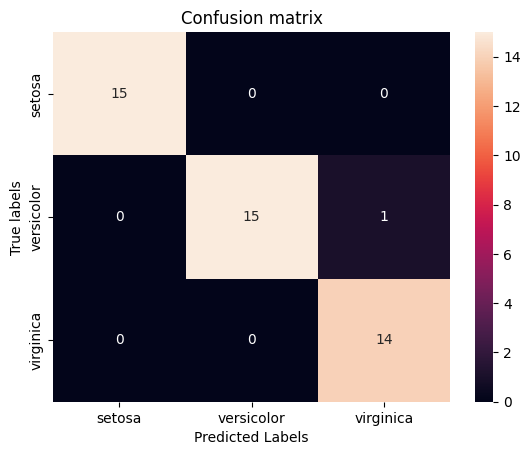

In [165]:
sns.heatmap(cm, xticklabels = iris.target_names, yticklabels = iris.target_names, annot = True)
plt.xlabel("Predicted Labels")
plt.ylabel("True labels")
plt.title("Confusion matrix")